In [1]:
import pandas as pd
import numpy as np

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [4]:
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
print('All libraries imported')

All libraries imported


In [5]:
df = pd.read_csv('insurance.csv')
print(f'Shape: {df.shape}')

Shape: (1338, 7)


In [6]:
df.head(10)

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
5,31,female,25.740,0,no,southeast,3756.62160
6,46,female,33.440,1,no,southeast,8240.58960
7,37,female,27.740,3,no,northwest,7281.50560
8,37,male,29.830,2,no,northeast,6406.41070
9,60,female,25.840,0,no,northwest,28923.13692


In [7]:
df.dtypes

age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object

In [8]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [9]:
for col in ['sex', 'smoker', 'region']:
    print(f'{col}: {df[col].unique()}')

sex: ['female' 'male']
smoker: ['yes' 'no']
region: ['southwest' 'southeast' 'northwest' 'northeast']


In [10]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [11]:
print(f'Duplicate rows: {df.duplicated().sum()}')
df = df.drop_duplicates()
print(f'Shape after dropping duplicates: {df.shape}')

Duplicate rows: 1
Shape after dropping duplicates: (1337, 7)


In [12]:
print('Negative/zero values check:')
for col in ['age', 'bmi', 'children', 'charges']:
    print(f'  {col}: min = {df[col].min():.2f}')

Negative/zero values check:
  age: min = 18.00
  bmi: min = 15.96
  children: min = 0.00
  charges: min = 1121.87


In [13]:
Q1 = df['charges'].quantile(0.25)
Q3 = df['charges'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
outliers = df[(df['charges'] < lower) | (df['charges'] > upper)]
print(f'Outliers in charges: {len(outliers)} rows')
print(f'Lower bound: {lower:.2f} | Upper bound: {upper:.2f}')

Outliers in charges: 139 rows
Lower bound: -13120.72 | Upper bound: 34524.78


In [14]:
Q1b = df['bmi'].quantile(0.25)
Q3b = df['bmi'].quantile(0.75)
IQRb = Q3b - Q1b
bmi_outliers = df[(df['bmi'] < Q1b - 1.5*IQRb) | (df['bmi'] > Q3b + 1.5*IQRb)]
print(f'Outliers in BMI: {len(bmi_outliers)} rows')

Outliers in BMI: 9 rows


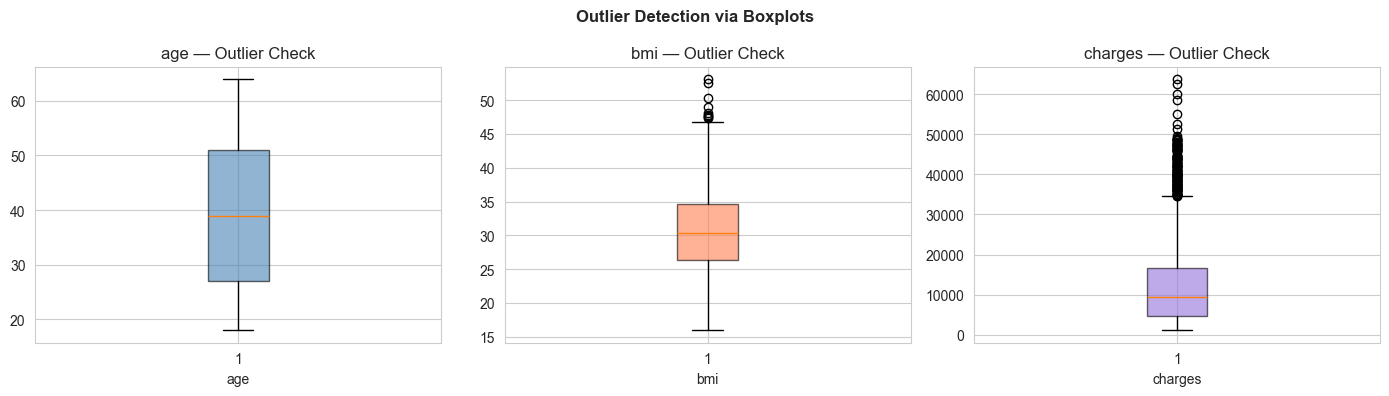

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col, color in zip(axes, ['age', 'bmi', 'charges'], ['steelblue', 'coral', 'mediumpurple']):
    ax.boxplot(df[col], patch_artist=True,
               boxprops=dict(facecolor=color, alpha=0.6))
    ax.set_title(f'{col} — Outlier Check')
    ax.set_xlabel(col)
plt.suptitle('Outlier Detection via Boxplots', fontweight='bold')
plt.tight_layout()
plt.show()

In [16]:
print(f'Final cleaned dataset shape: {df.shape}')
print('Data cleaning complete')

Final cleaned dataset shape: (1337, 7)
Data cleaning complete


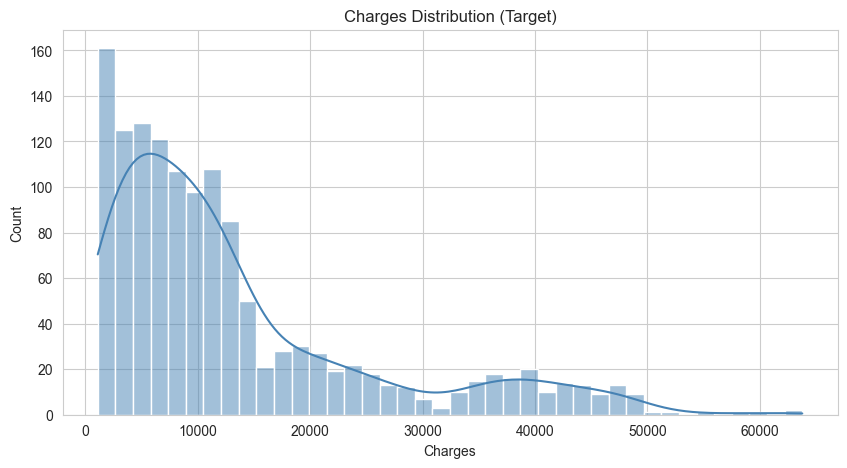

In [17]:
sns.histplot(df['charges'], kde=True, color='steelblue', bins=40)
plt.title('Charges Distribution (Target)')
plt.xlabel('Charges')
plt.show()

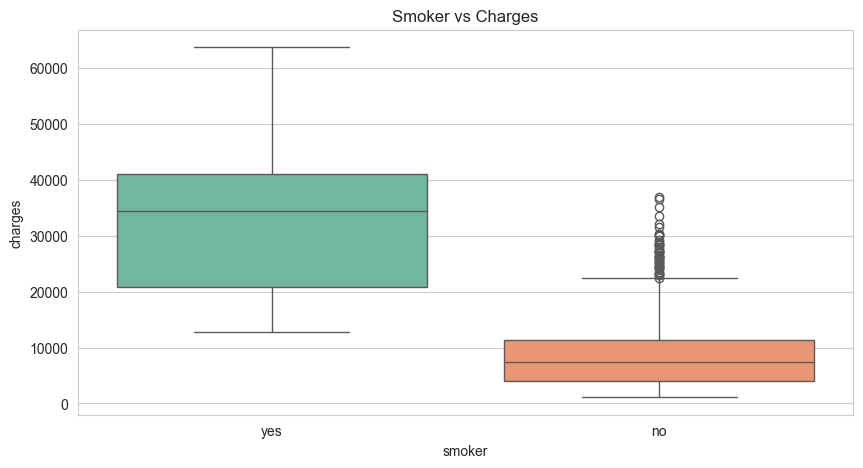

In [18]:
sns.boxplot(x='smoker', y='charges', data=df, palette='Set2')
plt.title('Smoker vs Charges')
plt.show()

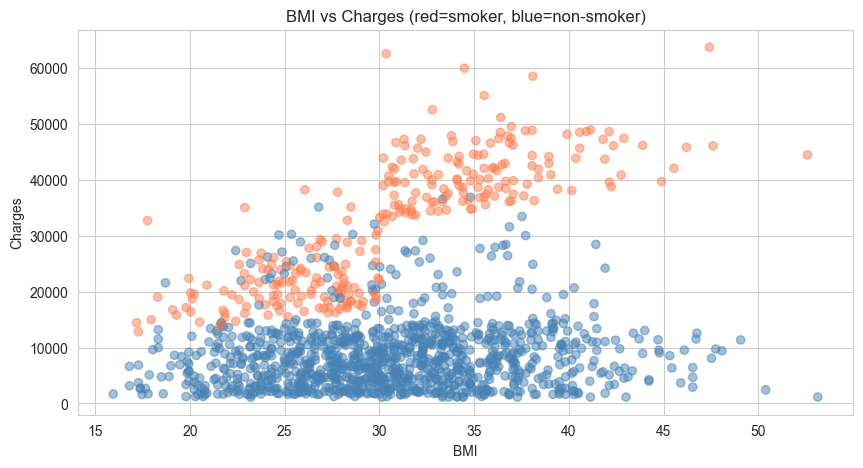

In [19]:
colors = df['smoker'].map({'yes': 'coral', 'no': 'steelblue'})
plt.scatter(df['bmi'], df['charges'], c=colors, alpha=0.5)
plt.title('BMI vs Charges (red=smoker, blue=non-smoker)')
plt.xlabel('BMI')
plt.ylabel('Charges')
plt.show()

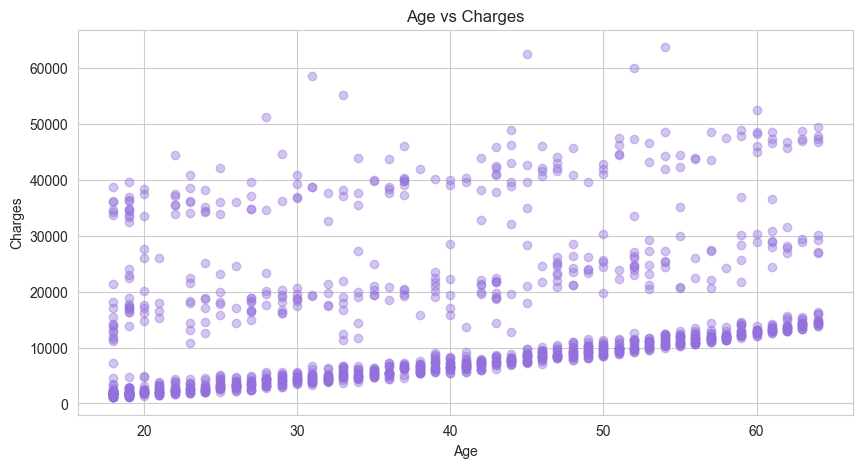

In [20]:
plt.scatter(df['age'], df['charges'], alpha=0.4, color='mediumpurple')
plt.title('Age vs Charges')
plt.xlabel('Age')
plt.ylabel('Charges')
plt.show()

In [21]:
def bmi_category(bmi):
    if bmi < 18.5: return 'underweight'
    elif bmi < 25: return 'normal'
    elif bmi < 30: return 'overweight'
    else:          return 'obese'

df['bmi_category'] = df['bmi'].apply(bmi_category)
df['bmi_category'].value_counts()

bmi_category
obese          706
overweight     386
normal         225
underweight     20
Name: count, dtype: int64

In [22]:
df['age_group'] = pd.cut(df['age'], bins=[17, 30, 45, 65],
                         labels=['young', 'middle', 'senior'])
df['age_group'].value_counts()

age_group
senior    500
young     443
middle    394
Name: count, dtype: int64

In [23]:
df['smoker_obese'] = ((df['smoker'] == 'yes') & (df['bmi'] >= 30)).astype(int)
df['smoker_obese'].value_counts()

smoker_obese
0    1192
1     145
Name: count, dtype: int64

In [24]:
df['log_charges'] = np.log1p(df['charges'])
print(f'Original skewness : {df["charges"].skew():.4f}')
print(f'Log skewness      : {df["log_charges"].skew():.4f}')

Original skewness : 1.5154
Log skewness      : -0.0896


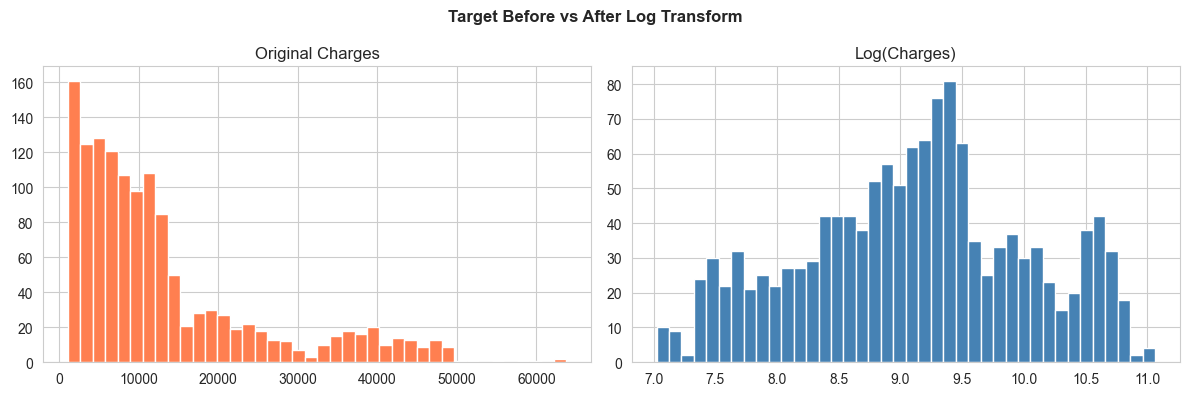

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df['charges'],     bins=40, color='coral',     edgecolor='white')
axes[0].set_title('Original Charges')
axes[1].hist(df['log_charges'], bins=40, color='steelblue', edgecolor='white')
axes[1].set_title('Log(Charges)')
plt.suptitle('Target Before vs After Log Transform', fontweight='bold')
plt.tight_layout()
plt.show()

In [26]:
print('New features added:')
print('  bmi_category, age_group, smoker_obese, log_charges')
df[['bmi', 'bmi_category', 'age', 'age_group', 'smoker', 'smoker_obese']].head(8)

New features added:
  bmi_category, age_group, smoker_obese, log_charges


,bmi,bmi_category,age,age_group,smoker,smoker_obese
0,27.900,overweight,19,young,yes,0
1,33.770,obese,18,young,no,0
2,33.000,obese,28,young,no,0
3,22.705,normal,33,middle,no,0
4,28.880,overweight,32,middle,no,0
5,25.740,overweight,31,middle,no,0
6,33.440,obese,46,senior,no,0
7,27.740,overweight,37,middle,no,0


In [27]:
feature_cols = ['age', 'sex', 'bmi', 'children', 'smoker', 'region',
                'bmi_category', 'age_group', 'smoker_obese']
X = df[feature_cols].copy()
y = df['log_charges']     # predicting log-transformed charges
print('Feature columns:', feature_cols)
print('Target: log_charges')

Feature columns: ['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'bmi_category', 'age_group', 'smoker_obese']
Target: log_charges


In [28]:
X['age_group'] = X['age_group'].astype(str)
X.dtypes

age               int64
sex              object
bmi             float64
children          int64
smoker           object
region           object
bmi_category     object
age_group        object
smoker_obese      int64
dtype: object

In [29]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)
print(f'Train size: {X_train.shape[0]} | Test size: {X_test.shape[0]}')

Train size: 1069 | Test size: 268


In [30]:
numeric_features = ['age', 'bmi', 'children', 'smoker_obese']
categorical_features = ['sex', 'smoker', 'region', 'bmi_category', 'age_group']

print('Numeric features   :', numeric_features)
print('Categorical features:', categorical_features)

Numeric features   : ['age', 'bmi', 'children', 'smoker_obese']
Categorical features: ['sex', 'smoker', 'region', 'bmi_category', 'age_group']


In [31]:
numeric_transformer = StandardScaler()
categorical_transformer = OneHotEncoder(handle_unknown='ignore', drop='first')

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer,    numeric_features),
    ('cat', categorical_transformer, categorical_features)
])
print('Preprocessor built')

Preprocessor built


In [33]:
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', Ridge())
])
print(' Full pipeline built!')
print(pipeline)

 Full pipeline built!
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['age', 'bmi', 'children',
                                                   'smoker_obese']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['sex', 'smoker', 'region',
                                                   'bmi_category',
                                                   'age_group'])])),
                ('model', Ridge())])


In [34]:
pipeline.fit(X_train, y_train)
print('Pipeline trained!')

Pipeline trained!


In [35]:
# Baseline predictions (log scale)
y_pred_log = pipeline.predict(X_test)

# Convert back to original scale
y_pred_orig = np.expm1(y_pred_log)
y_test_orig = np.expm1(y_test)

# Baseline metrics
mae_base  = mean_absolute_error(y_test_orig, y_pred_orig)
rmse_base = np.sqrt(mean_squared_error(y_test_orig, y_pred_orig))
r2_base   = r2_score(y_test_orig, y_pred_orig)

print('=== Baseline Pipeline (Ridge α=1.0) ===')
print(f'  MAE  : {mae_base:,.2f}')
print(f'  RMSE : {rmse_base:,.2f}')
print(f'  R²   : {r2_base:.4f}')

=== Baseline Pipeline (Ridge α=1.0) ===
  MAE  : 3,876.06
  RMSE : 7,719.80
  R²   : 0.6757


In [36]:
param_grid = {
    'model__alpha': [0.01, 0.1, 1.0, 10.0, 50.0, 100.0, 500.0]
}
print('Hyperparameter grid:')
print(param_grid)

Hyperparameter grid:
{'model__alpha': [0.01, 0.1, 1.0, 10.0, 50.0, 100.0, 500.0]}


In [37]:
grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring='r2',
    verbose=1,
    n_jobs=-1
)
grid_search.fit(X_train, y_train)
print(' GridSearchCV complete!')

Fitting 5 folds for each of 7 candidates, totalling 35 fits
 GridSearchCV complete!


In [38]:
print(f'Best alpha : {grid_search.best_params_}')
print(f'Best CV R² : {grid_search.best_score_:.4f}')

Best alpha : {'model__alpha': 1.0}
Best CV R² : 0.7661


In [39]:
cv_results = pd.DataFrame(grid_search.cv_results_)
cv_results[['param_model__alpha', 'mean_test_score', 'std_test_score']].sort_values(
    'mean_test_score', ascending=False)

,param_model__alpha,mean_test_score,std_test_score
2,1.00,0.766091,0.027125
1,0.10,0.766085,0.027108
0,0.01,0.766081,0.027104
3,10.00,0.763749,0.026685
4,50.00,0.741322,0.024973
5,100.00,0.716543,0.025327
6,500.00,0.596822,0.025532


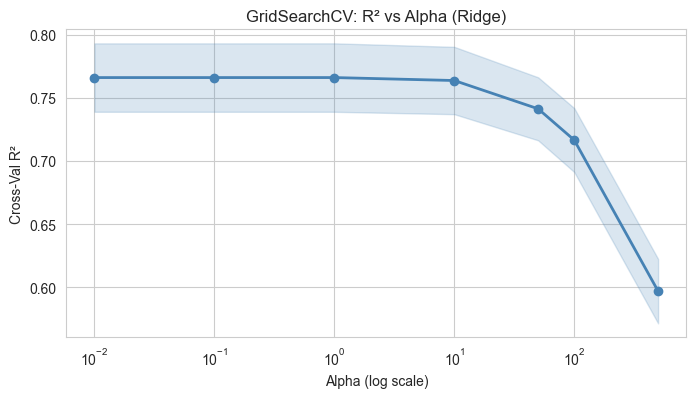

In [40]:
alphas_tried = cv_results['param_model__alpha'].astype(float)
mean_scores  = cv_results['mean_test_score']
std_scores   = cv_results['std_test_score']

plt.figure(figsize=(8, 4))
plt.plot(alphas_tried, mean_scores, marker='o', color='steelblue', linewidth=2)
plt.fill_between(alphas_tried,
                 mean_scores - std_scores,
                 mean_scores + std_scores,
                 alpha=0.2, color='steelblue')
plt.xscale('log')
plt.title('GridSearchCV: R² vs Alpha (Ridge)')
plt.xlabel('Alpha (log scale)')
plt.ylabel('Cross-Val R²')
plt.grid(True)
plt.show()

In [41]:
best_pipeline = grid_search.best_estimator_
best_alpha    = grid_search.best_params_['model__alpha']
print(f'Best pipeline uses Ridge with alpha={best_alpha}')

Best pipeline uses Ridge with alpha=1.0


In [42]:
y_pred_best_log  = best_pipeline.predict(X_test)
y_pred_best_orig = np.expm1(y_pred_best_log)
y_pred_best_orig[:5]

array([ 8112.64080617,  6162.71503377, 12995.72822607, 38714.74513329,
        5057.83681027])

In [43]:
mae_final  = mean_absolute_error(y_test_orig, y_pred_best_orig)
rmse_final = np.sqrt(mean_squared_error(y_test_orig, y_pred_best_orig))
r2_final   = r2_score(y_test_orig, y_pred_best_orig)

print(f'=== Final Tuned Pipeline (Ridge α={best_alpha}) ===')
print(f'  MAE  : {mae_final:,.2f}')
print(f'  RMSE : {rmse_final:,.2f}')
print(f'  R²   : {r2_final:.4f}')

=== Final Tuned Pipeline (Ridge α=1.0) ===
  MAE  : 3,876.06
  RMSE : 7,719.80
  R²   : 0.6757


In [44]:
cv_final = cross_val_score(best_pipeline, X_train, y_train, cv=5, scoring='r2')
print(f'Cross-Val R² (5-fold): {cv_final.mean():.4f} ± {cv_final.std():.4f}')

Cross-Val R² (5-fold): 0.7661 ± 0.0271


In [45]:
comparison = pd.DataFrame({
    'Model': ['Baseline (α=1.0)', f'Tuned (α={best_alpha})'],
    'MAE'  : [round(mae_base, 2),  round(mae_final, 2)],
    'RMSE' : [round(rmse_base, 2), round(rmse_final, 2)],
    'R²'   : [round(r2_base, 4),   round(r2_final, 4)]
})
comparison

,Model,MAE,RMSE,R²
0,Baseline (α=1.0),3876.06,7719.8,0.6757
1,Tuned (α=1.0),3876.06,7719.8,0.6757


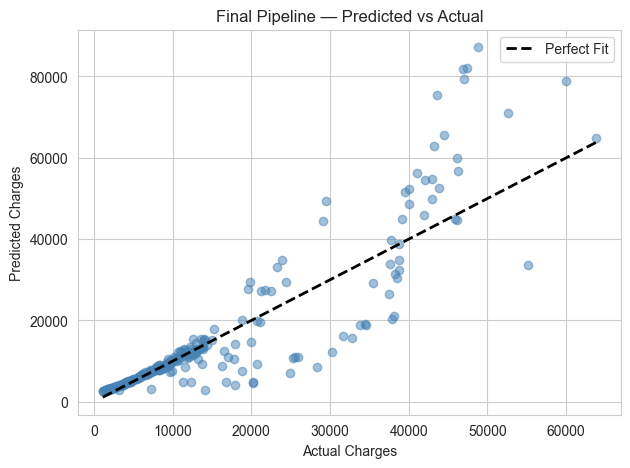

In [46]:
plt.figure(figsize=(7, 5))
plt.scatter(y_test_orig, y_pred_best_orig, alpha=0.5, color='steelblue')
plt.plot([y_test_orig.min(), y_test_orig.max()],
         [y_test_orig.min(), y_test_orig.max()], 'k--', lw=2, label='Perfect Fit')
plt.title('Final Pipeline — Predicted vs Actual')
plt.xlabel('Actual Charges')
plt.ylabel('Predicted Charges')
plt.legend()
plt.show()

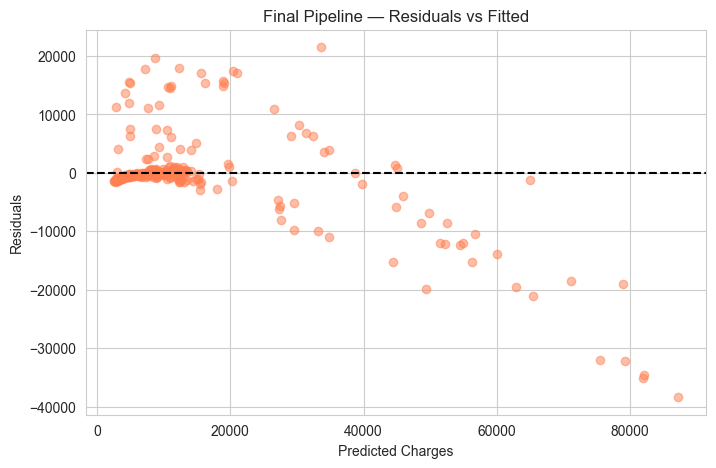

In [47]:
residuals = y_test_orig.values - y_pred_best_orig
plt.figure(figsize=(8, 5))
plt.scatter(y_pred_best_orig, residuals, alpha=0.5, color='coral')
plt.axhline(0, color='black', linestyle='--')
plt.title('Final Pipeline — Residuals vs Fitted')
plt.xlabel('Predicted Charges')
plt.ylabel('Residuals')
plt.show()

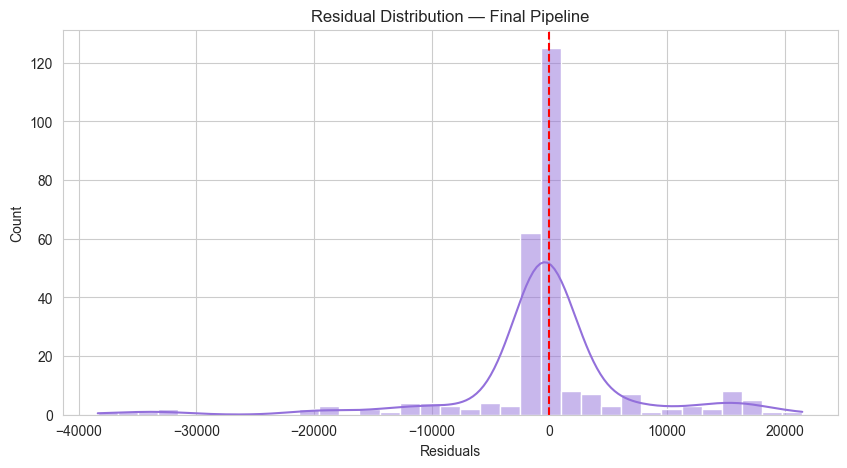

In [48]:
sns.histplot(residuals, kde=True, color='mediumpurple', bins=35)
plt.axvline(0, color='red', linestyle='--')
plt.title('Residual Distribution — Final Pipeline')
plt.xlabel('Residuals')
plt.show()

In [49]:
feature_names_num = numeric_features
feature_names_cat = best_pipeline.named_steps['preprocessor']\
    .named_transformers_['cat'].get_feature_names_out(categorical_features).tolist()
all_features = feature_names_num + feature_names_cat
coefficients  = best_pipeline.named_steps['model'].coef_

coef_df = pd.DataFrame({'Feature': all_features, 'Coefficient': coefficients})
coef_df = coef_df.sort_values('Coefficient', key=abs, ascending=False)
coef_df.head(15)

,Feature,Coefficient
5,smoker_yes,1.196543
0,age,0.489588
11,bmi_category_underweight,-0.209945
3,smoker_obese,0.199729
2,children,0.119706
7,region_southeast,-0.118829
8,region_southwest,-0.117950
4,sex_male,-0.088380
6,region_northwest,-0.037439
12,age_group_senior,-0.021974


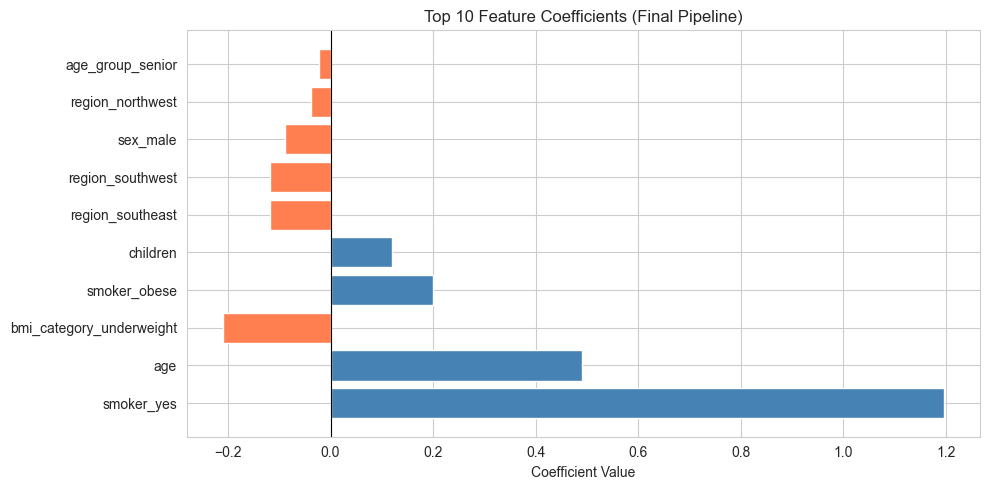

In [50]:
top10 = coef_df.head(10)
colors_coef = ['steelblue' if c > 0 else 'coral' for c in top10['Coefficient']]
plt.figure(figsize=(10, 5))
plt.barh(top10['Feature'], top10['Coefficient'], color=colors_coef, edgecolor='white')
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Top 10 Feature Coefficients (Final Pipeline)')
plt.xlabel('Coefficient Value')
plt.tight_layout()
plt.show()

In [52]:
os.makedirs('saved_model', exist_ok=True)
print('Directory created: saved_model/')

Directory created: saved_model/


In [54]:
model_path = 'saved_model/insurance_pipeline.pkl'
joblib.dump(best_pipeline, model_path)
print(f'Model saved to: {model_path}')

Model saved to: saved_model/insurance_pipeline.pkl


In [55]:
size_kb = os.path.getsize(model_path) / 1024
print(f'Model file size: {size_kb:.2f} KB')

Model file size: 4.46 KB


In [56]:
loaded_pipeline = joblib.load(model_path)
print('Model loaded successfully!')
print(f'Type: {type(loaded_pipeline)}')

Model loaded successfully!
Type: <class 'sklearn.pipeline.Pipeline'>


In [57]:
y_pred_loaded = np.expm1(loaded_pipeline.predict(X_test))
match = np.allclose(y_pred_loaded, y_pred_best_orig)
print(f'Loaded model predictions match original: {match} ')

Loaded model predictions match original: True 


In [58]:
new_patient = pd.DataFrame({
    'age'         : [35],
    'sex'         : ['male'],
    'bmi'         : [28.5],
    'children'    : [2],
    'smoker'      : ['no'],
    'region'      : ['southeast'],
    'bmi_category': ['overweight'],
    'age_group'   : ['middle'],
    'smoker_obese': [0]
})
new_patient

,age,sex,bmi,children,smoker,region,bmi_category,age_group,smoker_obese
0,35,male,28.5,2,no,southeast,overweight,middle,0


In [59]:
pred_log = loaded_pipeline.predict(new_patient)
pred_charge = np.expm1(pred_log)[0]
print(f'Predicted insurance charge: ${pred_charge:,.2f}')

Predicted insurance charge: $5,689.60


In [60]:
high_risk = pd.DataFrame({
    'age'         : [52],
    'sex'         : ['female'],
    'bmi'         : [38.0],
    'children'    : [1],
    'smoker'      : ['yes'],
    'region'      : ['northeast'],
    'bmi_category': ['obese'],
    'age_group'   : ['senior'],
    'smoker_obese': [1]
})
pred_high = np.expm1(loaded_pipeline.predict(high_risk))[0]
print(f'High-risk patient predicted charge: ${pred_high:,.2f}')

High-risk patient predicted charge: $73,855.50
